2025-05-26 15:55:39.499641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748274939.705400      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748274939.770632      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1748274951.916268      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train directory exists: True
Test directory exists: True
Found 2142 images belonging to 2 classes.
Found 1821 images belonging to 2 classes.
Found 321 images belonging to 2 classes.
Found 45 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1748274975.358720      93 cuda_dnn.cc:529] Loaded cuDNN version 90300


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6490 - auc: 0.7129 - loss: 37.8975 - precision: 0.6490 - recall: 0.6490

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6507 - auc: 0.7147 - loss: 37.7699 - precision: 0.6507 - recall: 0.6507 - val_accuracy: 0.5688 - val_auc: 0.6290 - val_loss: 27.3457 - val_precision: 0.5688 - val_recall: 0.5688 - learning_rate: 0.0010
Epoch 2/20
 1/28 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.8125 - auc: 0.8450 - loss: 26.8466 - precision: 0.8125 - recall: 0.8125

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 621ms/step - accuracy: 0.8125 - auc: 0.8450 - loss: 26.8466 - precision: 0.8125 - recall: 0.8125 - val_accuracy: 0.5719 - val_auc: 0.6517 - val_loss: 26.7041 - val_precision: 0.5719 - val_recall: 0.5719 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7764 - auc: 0.8582 - loss: 23.5194 - precision: 0.7764 - recall: 0.7764 - val_accuracy: 0.7000 - val_auc: 0.7838 - val_loss: 16.0055 - val_precision: 0.7000 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 548ms/step - accuracy: 0.7656 - auc: 0.8713 - loss: 15.8621 - precision: 0.7656 - recall: 0.7656 - val_accuracy: 0.6750 - val_auc: 0.7206 - val_loss: 15.8175 - val_precision: 0.6750 - val_recall: 0.6750 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7836 - auc: 0.8656 - loss: 13.8826 - precision: 0.7836 - recall: 0.7836 - val_accuracy: 0.6906 - val_auc: 0.7291 - val_loss: 9.5713 - val_preci

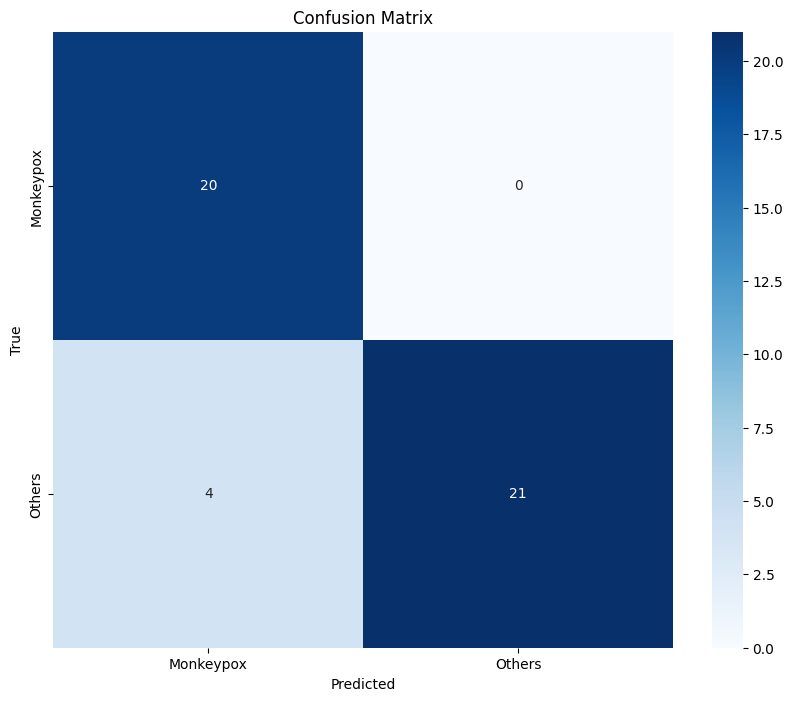


Final Test Metrics:
accuracy: 0.9111
auc: 0.9474
loss: 3.2851
precision: 0.9111
recall: 0.9111


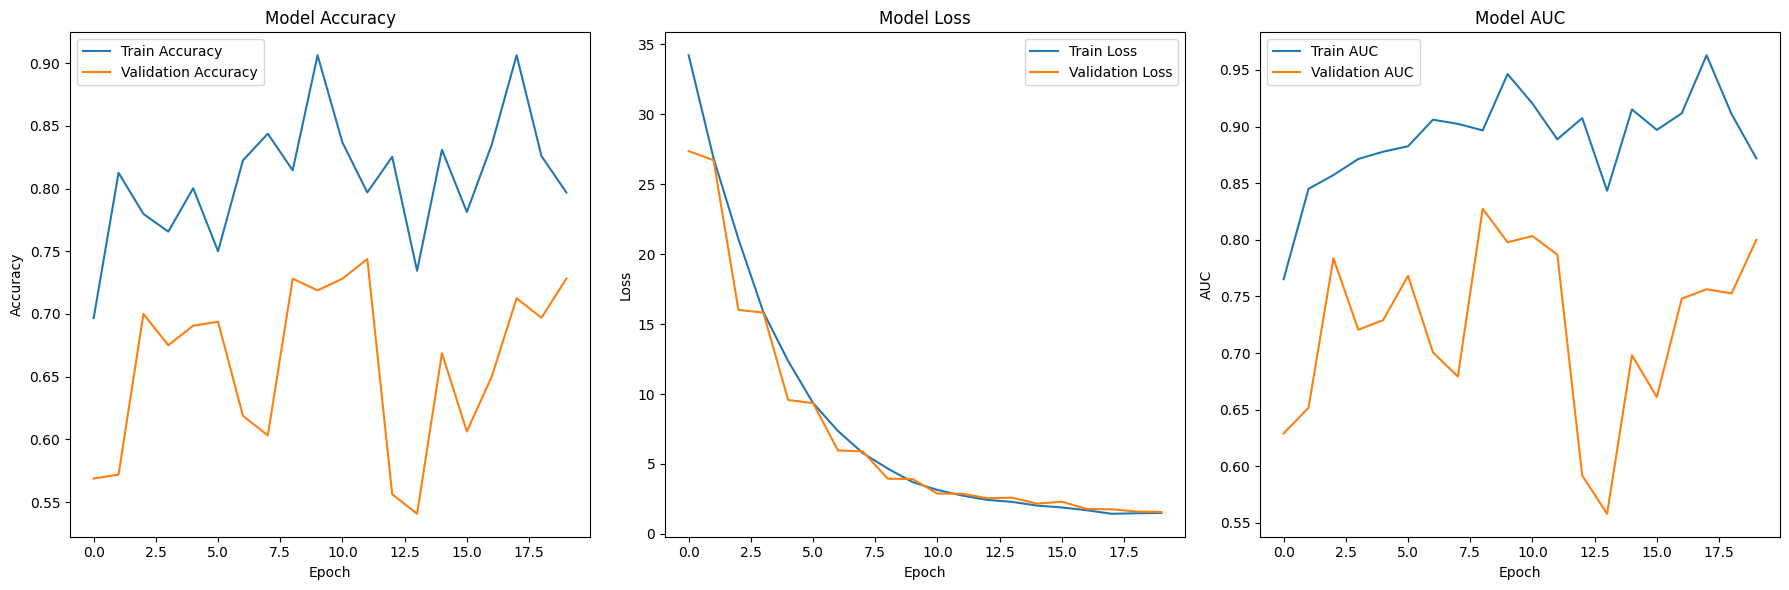

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout, 
                                    BatchNormalization, Activation, GaussianNoise)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, 
                                      ModelCheckpoint, TensorBoard)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import classification_report, confusion_matrix
import os
import random
import cv2
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Accelerator setup (GPU/TPU)
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
except:
    strategy = tf.distribute.MirroredStrategy()

# Correct paths
base_dir = '/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1'
train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

# Verify paths
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

# Get class names and compute class weights
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Compute class weights for imbalanced data
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(train_dir, shuffle=True)
class_weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), 
                                   y=train_gen.classes)
class_weight_dict = {i: class_weights[i] for i in range(num_classes)}

# Enhanced data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=50,
    fill_mode='reflect',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators with larger batch size
BATCH_SIZE = 64
IMG_SIZE = 320  # Slightly larger than default Inception input

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Enhanced model architecture
with strategy.scope():
    # Load InceptionV3 with custom input size
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Add advanced custom head
    x = base_model.output
    x = GaussianNoise(0.1)(x)  # Regularization
    x = GlobalAveragePooling2D()(x)
    
    # Enhanced dense layers with regularization
    x = Dense(2048, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.6)(x)
    
    x = Dense(1024, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.5)(x)
    
    x = Dense(512, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.4)(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Custom learning rate schedule
    initial_learning_rate = 0.001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=1000,
        decay_rate=0.96,
        staircase=True
    )
    
    # Enhanced optimizer
    optimizer = Adam(
        learning_rate=lr_schedule,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07,
        amsgrad=True
    )
    
    # Compile with additional metrics
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), 
                Recall(name='recall'), AUC(name='auc')]
    )

# Enhanced callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        verbose=1,
        mode='max',
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        min_lr=1e-7,
        mode='min'
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    ),
    TensorBoard(
        log_dir='./logs',
        histogram_freq=1,
        update_freq='epoch'
    )
]

# Initial training (feature extraction)
EPOCHS = 20
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Fine-tuning phase
with strategy.scope():
    # Unfreeze deeper layers
    for layer in base_model.layers[-100:]:
        layer.trainable = True
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), 
                Recall(name='recall'), AUC(name='auc')]
    )

# Fine-tune for fewer epochs
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Load best model
model.load_weights('best_model.h5')

# Enhanced evaluation
def comprehensive_evaluation(model, generator):
    results = {}
    
    # Standard metrics
    eval_metrics = model.evaluate(generator, return_dict=True)
    results.update(eval_metrics)
    
    # Predictions for additional metrics
    generator.reset()
    y_pred = model.predict(generator)
    y_true = generator.classes
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Classification report
    print("\nEnhanced Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=classes))
    
    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return results

# Run comprehensive evaluation
test_results = comprehensive_evaluation(model, test_generator)
print("\nFinal Test Metrics:")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")

# Enhanced visualization
def plot_training_history(history):
    plt.figure(figsize=(18, 6))
    
    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    # Loss plot
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    # AUC plot
    plt.subplot(1, 3, 3)
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title('Model AUC')
    plt.ylabel('AUC')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Display sample predictions with confidence
# Display sample predictions with confidence
def show_enhanced_predictions(num_images=5):
    plt.figure(figsize=(20, 10))
    random_indices = random.sample(range(len(test_generator.filenames)), num_images)
    
    for i, idx in enumerate(random_indices):
        img_path = os.path.join(test_dir, test_generator.filenames[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Preprocess exactly like training
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.applications.inception_v3.preprocess_input(
            np.expand_dims(img_resized, axis=0))
        
        # Predict with confidence
        pred = model.predict(img_array)
        pred_class = classes[np.argmax(pred)]
        true_class = classes[test_generator.classes[idx]]
        confidence = np.max(pred)
        
        # Get top 3 predictions
        top3_idx = np.argsort(pred[0])[::-1][:3]
        top3_classes = [classes[i] for i in top3_idx]
        top3_conf = [pred[0][i] for i in top3_idx]
        
        # Plot
        plt.subplot(2, num_images, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}")
        plt.axis('off')
        
        plt.subplot(2, num_images, i+1+num_images)
        plt.barh(top3_classes, top3_conf)
        plt.title('Top 3 Predictions')
        plt.xlim(0, 1)
    
    plt.tight_layout()
    plt.show()